# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.simplefilter('ignore')
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

### Data Loading

In [2]:
data=pd.read_csv('exchange_rate.csv')
data

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [4]:
data.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [5]:
data.isnull().sum()

,0
date,0
Ex_rate,0


In [23]:
data = pd.read_csv('exchange_rate.csv') # Reload data to ensure 'date' column is present
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y %H:%M')
data.set_index('date', inplace=True)

In [7]:
data

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


### Initial Exploration

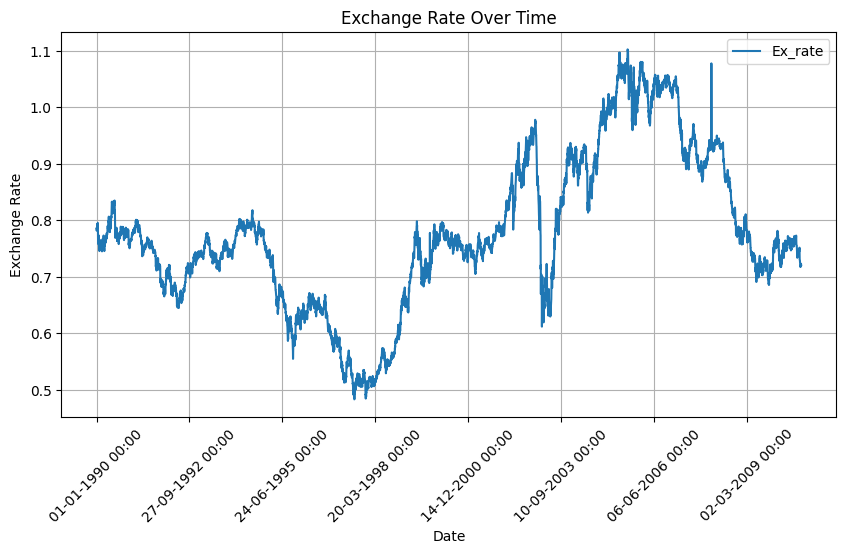

In [8]:
data.plot(figsize=(10,5))
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [9]:
decompose=seasonal_decompose(data['Ex_rate'], model='additive', period=10)

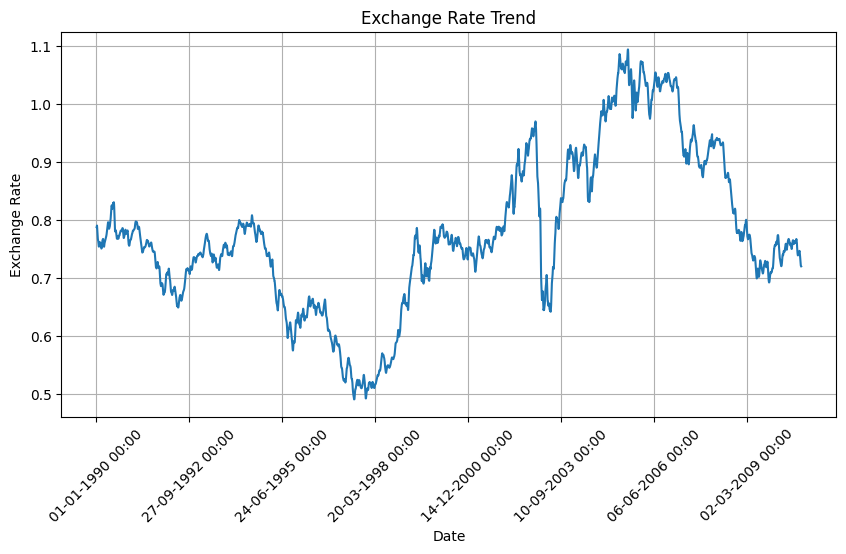

In [10]:
decompose.trend.plot(figsize=(10,5))
plt.title('Exchange Rate Trend')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

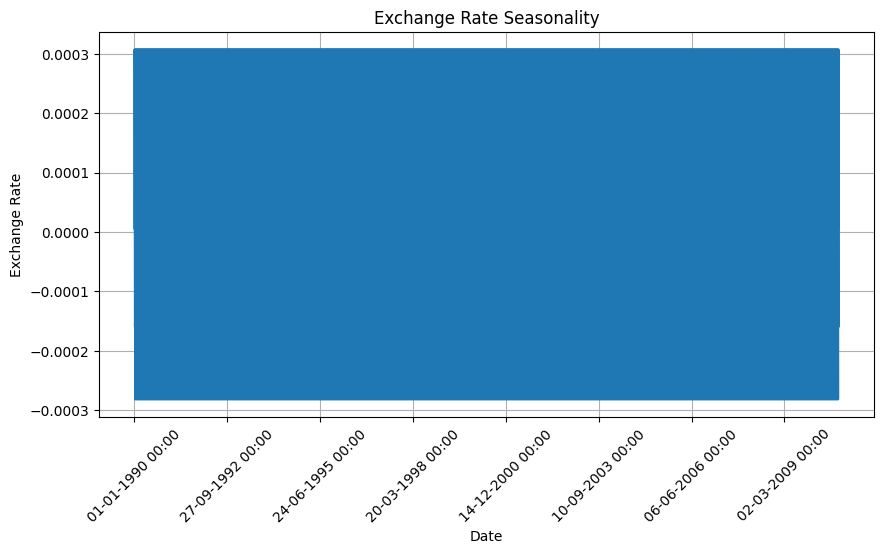

In [11]:
decompose.seasonal.plot(figsize=(10,5))
plt.title('Exchange Rate Seasonality')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


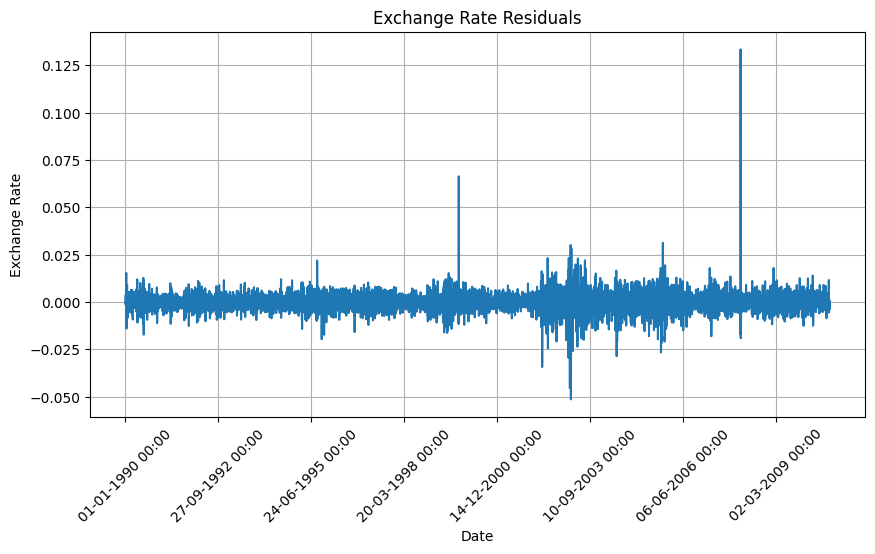

In [12]:
decompose.resid.plot(figsize=(10,5))
plt.title('Exchange Rate Residuals')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## ACF and PACF plots And ADFULLER model

In [13]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] > 0.05:
        print("Time series is not stationary.Differencing is needed")
    else:
        print("Time series is stationary.")

check_stationarity(data['Ex_rate'])

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477
Time series is not stationary.Differencing is needed


In [14]:
data_diff=data['Ex_rate'].diff().dropna()
check_stationarity(data_diff)

ADF Statistic: -99.39343120118632
p-value: 0.0
Time series is stationary.


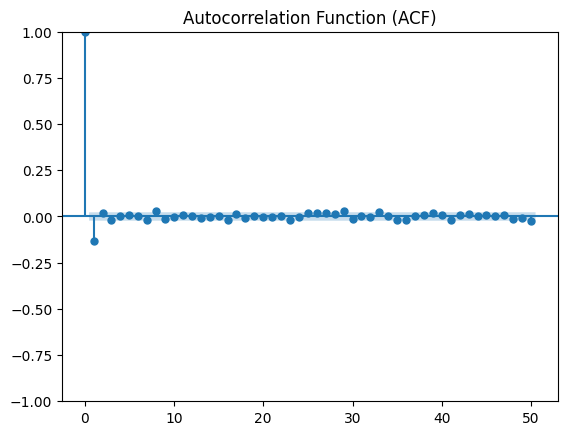

In [15]:
plot_acf(data_diff,lags=50,ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')
plt.show()

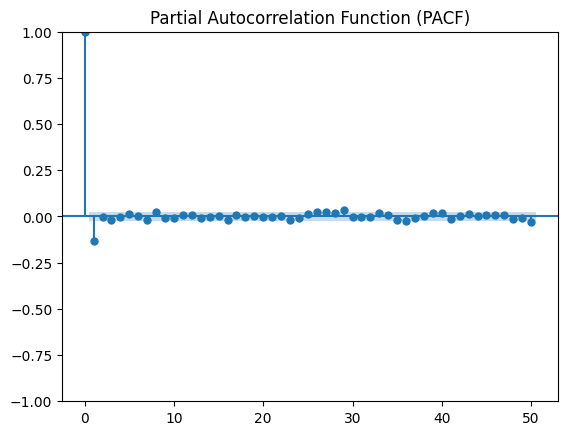

In [16]:
plot_pacf(data_diff,lags=50,ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

##### Therefore,(p,d,q)=(1,1,1)

## ARIMA model

In [24]:
warnings.simplefilter('ignore')

# Split data for ARIMA model consistently with Exponential Smoothing
train_arima = data['Ex_rate'].iloc[:-30]
test_arima = data['Ex_rate'].iloc[-30:]

model_arima = ARIMA(train_arima, order=(1,1,1))
arima_result = model_arima.fit()

# Generate forecast for the test period
# The forecast method returns a Series with a numerical index by default, so align it with test_arima's index
forecast_arima = arima_result.predict(start=len(train_arima), end=len(data['Ex_rate']) - 1)
forecast_arima.index = test_arima.index

In [18]:
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Fri, 25 Sep 2026   AIC                         -56102.322
Time:                        12:37:14   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.000    3.58e-05    3.62e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2865078.33
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.97   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                        98.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

(array([-1000.,     0.,  1000.,  2000.,  3000.,  4000.,  5000.,  6000.,
         7000.,  8000.]),
 [Text(-1000.0, 0, '15-01-2008 00:00'),
  Text(0.0, 0, '01-01-1990 00:00'),
  Text(1000.0, 0, '27-09-1992 00:00'),
  Text(2000.0, 0, '24-06-1995 00:00'),
  Text(3000.0, 0, '20-03-1998 00:00'),
  Text(4000.0, 0, '14-12-2000 00:00'),
  Text(5000.0, 0, '10-09-2003 00:00'),
  Text(6000.0, 0, '06-06-2006 00:00'),
  Text(7000.0, 0, '02-03-2009 00:00'),
  Text(8000.0, 0, '')])

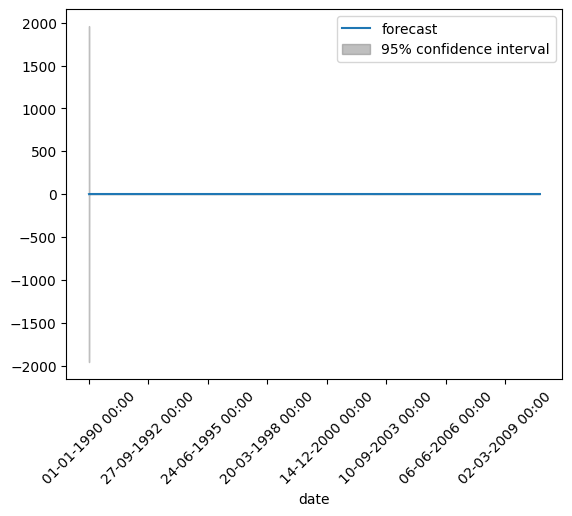

In [19]:
plot_predict(arima_result)
plt.xticks(rotation=45)

## Exponential Smoothing

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 7558
Model:             ExponentialSmoothing   SSE                              0.272
Optimized:                         True   AIC                         -77316.493
Trend:                         Additive   BIC                         -77288.771
Seasonal:                          None   AICC                        -77316.482
Seasonal Periods:                  None   Date:                 Fri, 25 Sep 2026
Box-Cox:                          False   Time:                         12:39:43
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8695087                alpha                 True
smoothing_trend             0.0000

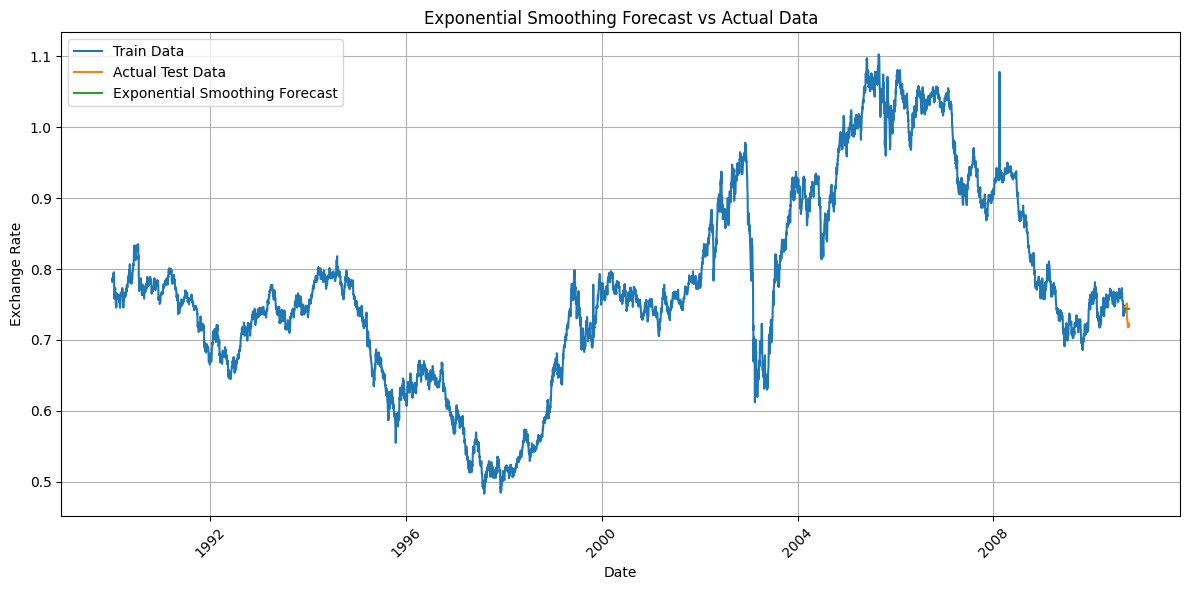

In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Re-load data to ensure a proper DatetimeIndex for Exponential Smoothing
data_es = pd.read_csv('exchange_rate.csv')
data_es['date'] = pd.to_datetime(data_es['date'], format='%d-%m-%Y %H:%M')
data_es.set_index('date', inplace=True)

# Split data into training and testing sets
train_data = data_es['Ex_rate'].iloc[:-30]
test_data = data_es['Ex_rate'].iloc[-30:]

# 1. Model Selection: Using Holt's Linear (additive trend, no seasonality) as seasonal_decompose showed no clear seasonality.
# 2. Parameter Optimization: The 'optimized=True' argument allows statsmodels to find optimal parameters.
# 3. Model Fitting and Forecasting
model_es = ExponentialSmoothing(train_data, trend='add', seasonal=None, seasonal_periods=None)
fit_es = model_es.fit(optimized=True)

# Forecast future values
forecast_es = fit_es.forecast(steps=len(test_data))

# Print model summary
print(fit_es.summary())

# Compare these forecasts visually with the actual data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label='Train Data')
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(forecast_es.index, forecast_es, label='Exponential Smoothing Forecast')
plt.title('Exponential Smoothing Forecast vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def calculate_metrics(actual, forecast, model_name):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    print(f'--- {model_name} Model Evaluation ---\nMAE: {mae:.4f}\nRMSE: {rmse:.4f}\nMAPE: {mape:.4f}%\n')

# Evaluate ARIMA model
calculate_metrics(test_arima, forecast_arima, 'ARIMA')

# Evaluate Exponential Smoothing model (using previously defined test_data and forecast_es)
calculate_metrics(test_data, forecast_es, 'Exponential Smoothing')

--- ARIMA Model Evaluation ---
MAE: 0.0135
RMSE: 0.0166
MAPE: 1.8632%

--- Exponential Smoothing Model Evaluation ---
MAE: 0.0134
RMSE: 0.0165
MAPE: 1.8532%



**Comparison of the Models:**

Upon visual inspection, both models' residuals generally fluctuate around zero, which is a good sign. However, small variations or occasional spikes in the plots indicate areas where the models might not perfectly capture the true underlying process.
The ARIMA model assumes linearity where it assumes a linear relationship between past and present values which might not hold true for all time-series with complex non-linear patterns. On the other hand, it has a strong statistical foundation for handling autocorrelated time series data, particularly when the data is stationary or can be made stationary through differencing.
The Exponential Smoothing Model we used is Holt's Linear as the decompose.seasonal.plot showed no seasonality. Exponential Smoothing models are generally simpler to understand and implement compared to ARIMA.

**Conclusion:**

For this particular exchange rate dataset, both ARIMA and Exponential Smoothing models provide strong and comparable forecasting performance. The Exponential Smoothing model shows a slighlty better performance with marginally lower MAE, RMSE and MAPE values. Given the slightly better metrics and the often simpler implementation of Exponential Smoothing, it could be the preferred choice for this specific scenario.